### Reproducible Research Group-6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Load data
dxy = pd.read_csv(DATA_DIR / "USD_Index.csv", parse_dates=["observation_date"], index_col="observation_date")
tsy = pd.read_csv(DATA_DIR / "Treasury_Yield.csv", parse_dates=["observation_date"], index_col="observation_date")

# Merge
df = dxy.join(tsy, how="inner")
df.columns = ["DXY", "Yield_10Y"]
df = df.dropna()

print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Observations: {len(df)}")
df.tail()

Date range: 2010-01-04 to 2026-04-17
Observations: 4045


,DXY,Yield_10Y
observation_date,,
2026-04-13,118.9916,4.30
2026-04-14,118.3581,4.26
2026-04-15,118.3623,4.29
2026-04-16,118.3616,4.32
2026-04-17,118.0795,4.26


In [3]:
# Key tariff event dates
events = {
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day",
    "2025-04-09": "90-day pause",
}

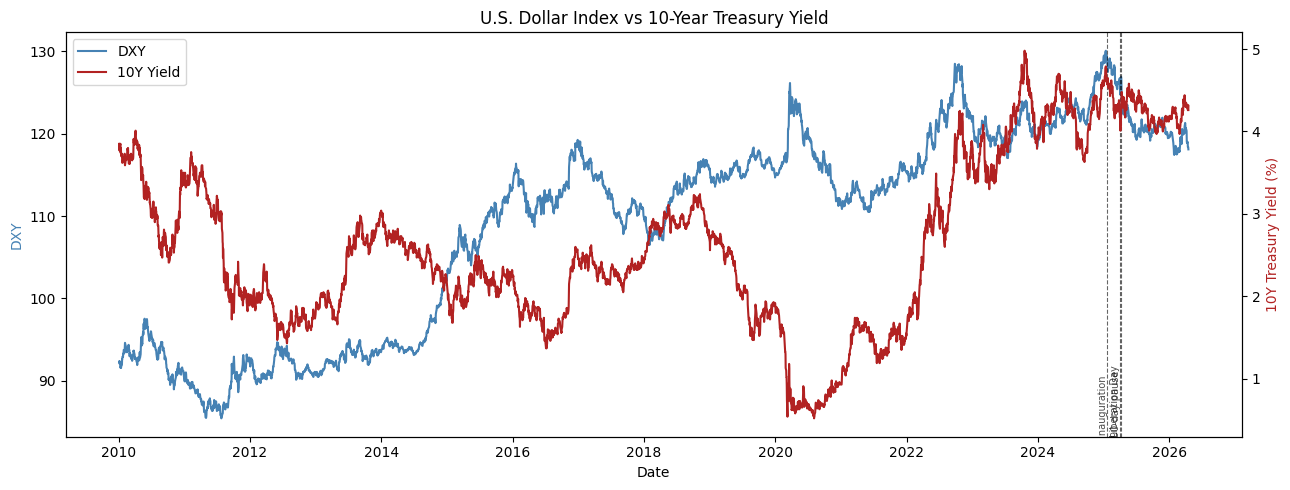

In [4]:
# Plot 1: DXY and 10Y yield over time (dual axis)
fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax1.plot(df.index, df["DXY"], color="steelblue", linewidth=1.5, label="DXY")
ax2.plot(df.index, df["Yield_10Y"], color="firebrick", linewidth=1.5, label="10Y Yield")

for date, label in events.items():
    ax1.axvline(pd.to_datetime(date), color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[0], label, rotation=90,
             fontsize=7, va="bottom", ha="right", alpha=0.7)

ax1.set_ylabel("DXY", color="steelblue")
ax2.set_ylabel("10Y Treasury Yield (%)", color="firebrick")
ax1.set_xlabel("Date")
ax1.set_title("U.S. Dollar Index vs 10-Year Treasury Yield")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_dxy_yield_over_time.png", dpi=150)
plt.show()

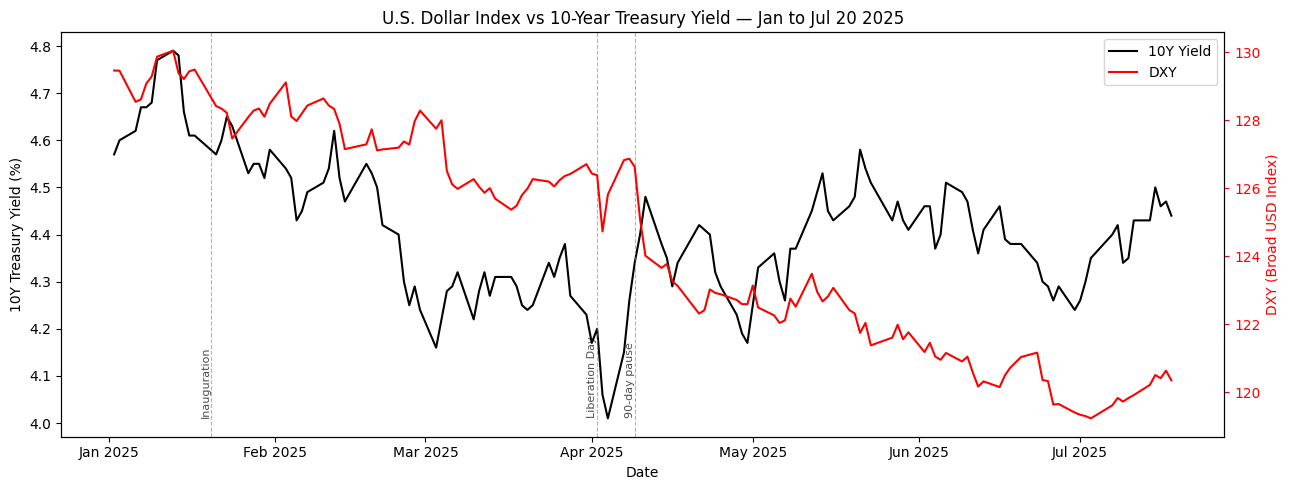

In [10]:
# Plot 2: DXY and 10Y yield — Jan 1 2025 to Jul 20 2025 (dual axis)
df_window = df[(df.index >= "2025-01-01") & (df.index <= "2025-07-20")]

fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax1.plot(df_window.index, df_window["Yield_10Y"], color="black", linewidth=1.5, label="10Y Yield")
ax2.plot(df_window.index, df_window["DXY"], color="red", linewidth=1.5, label="DXY")

for date, label in events.items():
    dt = pd.to_datetime(date)
    if pd.to_datetime("2025-01-01") <= dt <= pd.to_datetime("2025-07-20"):
        ax1.axvline(dt, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax1.text(dt, df_window["Yield_10Y"].min(), label, rotation=90,
                 fontsize=8, va="bottom", ha="right", alpha=0.7)

ax1.set_ylabel("10Y Treasury Yield (%)", color="black")
ax2.set_ylabel("DXY (Broad USD Index)", color="red")
ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')
ax1.set_xlabel("Date")
ax1.set_title("U.S. Dollar Index vs 10-Year Treasury Yield — Jan to Jul 20 2025")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_dxy_yield_jan_jul2025.png", dpi=150)
plt.show()

###  Article ends here, extended research begins


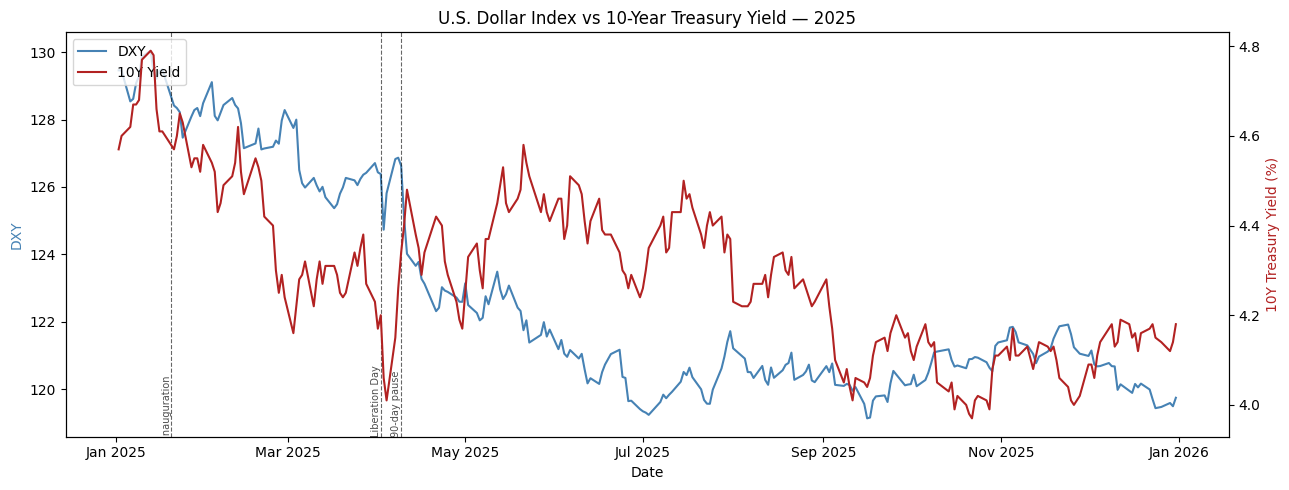

In [6]:
# Plot 4: DXY and 10Y yield — 2025 only (dual axis)
df_2025 = df[df.index.year == 2025]

fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax1.plot(df_2025.index, df_2025["DXY"], color="steelblue", linewidth=1.5, label="DXY")
ax2.plot(df_2025.index, df_2025["Yield_10Y"], color="firebrick", linewidth=1.5, label="10Y Yield")

for date, label in events.items():
    dt = pd.to_datetime(date)
    if dt.year == 2025:
        ax1.axvline(dt, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax1.text(dt, ax1.get_ylim()[0], label, rotation=90,
                 fontsize=7, va="bottom", ha="right", alpha=0.7)

ax1.set_ylabel("DXY", color="steelblue")
ax2.set_ylabel("10Y Treasury Yield (%)", color="firebrick")
ax1.set_xlabel("Date")
ax1.set_title("U.S. Dollar Index vs 10-Year Treasury Yield — 2025")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_dxy_yield_2025.png", dpi=150)
plt.show()

In [7]:
# Save combined dataset
df.to_csv(DATA_DIR / "combined.csv")
print("Combined data saved to data/combined.csv")

Combined data saved to data/combined.csv
